# TICKLE Step 3 — Contest Log Analysis
Ground-truth analysis of ARRL 10 GHz & Up logs (2019–2025) for the SD↔AZ
cloud-bounce corridor. Reads `contest_qsos.db` built by `parse_contest_logs.py`.

Requires: `pip install pandas matplotlib jupyter` in the TICKLE venv.
Run from the directory containing `contest_qsos.db` (or edit DB_PATH).

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "contest_qsos.db"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    """SELECT * FROM qsos
       WHERE band_ghz BETWEEN 9.5 AND 11
       AND lat1 IS NOT NULL AND lat2 IS NOT NULL""", conn,
    parse_dates=["ts"])
print(f"{len(df):,} 10 GHz QSO lines with valid grids")

/var/folders/fb/5kmw9fg16vl_h94dp_3t4yb80000gq/T/ipykernel_88098/2281197932.py:4: MatplotlibDeprecationWarning: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  import matplotlib.pyplot as plt
Matplotlib is building the font cache; this may take a moment.


64,169 10 GHz QSO lines with valid grids


In [2]:
# --- corridor definition (generous boxes; Step 2 geometry will refine) ---
def in_socal(lat, lon):  return (32.0 <= lat <= 34.5) and (-118.5 <= lon <= -115.8)
def in_azdes(lat, lon):  return (31.5 <= lat <= 35.5) and (-115.8 <= lon <= -110.5)

s1 = df.apply(lambda r: in_socal(r.lat1, r.lon1), axis=1)
s2 = df.apply(lambda r: in_socal(r.lat2, r.lon2), axis=1)
a1 = df.apply(lambda r: in_azdes(r.lat1, r.lon1), axis=1)
a2 = df.apply(lambda r: in_azdes(r.lat2, r.lon2), axis=1)
df["is_corridor"] = (s1 & a2) | (s2 & a1)

# dedupe QSOs logged by both sides: same timestamp + same unordered call pair
df["pair_key"] = df.apply(
    lambda r: (r.ts.isoformat(),) + tuple(sorted([r.call1, r.call2])), axis=1)
corridor = df[df.is_corridor].drop_duplicates("pair_key").copy()

# normalize so column 1 = SoCal end, column 2 = AZ end
flip = corridor.apply(lambda r: in_socal(r.lat2, r.lon2), axis=1)
for c1, c2 in [("call1","call2"), ("grid1","grid2"),
               ("lat1","lat2"), ("lon1","lon2")]:
    corridor.loc[flip, [c1, c2]] = corridor.loc[flip, [c2, c1]].values

print(f"{len(corridor)} unique corridor QSOs")
corridor[["ts","call1","grid1","call2","grid2","dist_km"]].head(10)

90 unique corridor QSOs


,ts,call1,grid1,call2,grid2,dist_km
625,2022-09-17 21:05:00,WA6CDR,DM13ET,WB6CWN,DM43BO,532.310433
1444,2022-08-20 20:20:00,WA6MEM,DM03TS,N6RMJ,DM24RV,373.518224
1445,2022-08-20 20:26:00,W6DL,DM13ET,N6RMJ,DM24RV,307.593832
1446,2022-08-20 20:27:00,KK6MXP,DM13ET,N6RMJ,DM24RV,307.593832
1447,2022-08-20 20:30:00,WA6JBD,DM13EI,N6RMJ,DM24RV,331.543915
1448,2022-08-20 20:31:00,N6CA,DM03UT,N6RMJ,DM24RV,364.682794
1449,2022-08-20 20:50:00,WA6CGR,DM03UT,N6RMJ,DM24RV,364.682794
1450,2022-08-20 22:50:00,N6CA,DM03UT,N6RMJ,DM25QA,362.156795
1451,2022-08-20 23:22:00,WA6JBD,DM13ET,N6RMJ,DM25QA,306.219302
1452,2022-08-20 23:24:00,W6DL,DM13ET,N6RMJ,DM25QA,306.219302


## When does the corridor work? (activity-controlled)
Corridor QSOs vs a control of short-range (<100 km) SoCal QSOs. The control
tracks *operator effort*; the corridor tracks *effort × propagation*.
A corridor deficit at the control's peak hour (19z ≈ local noon, pre-convective)
and a surplus during convective hours (20z–03z) is the monsoon signature.

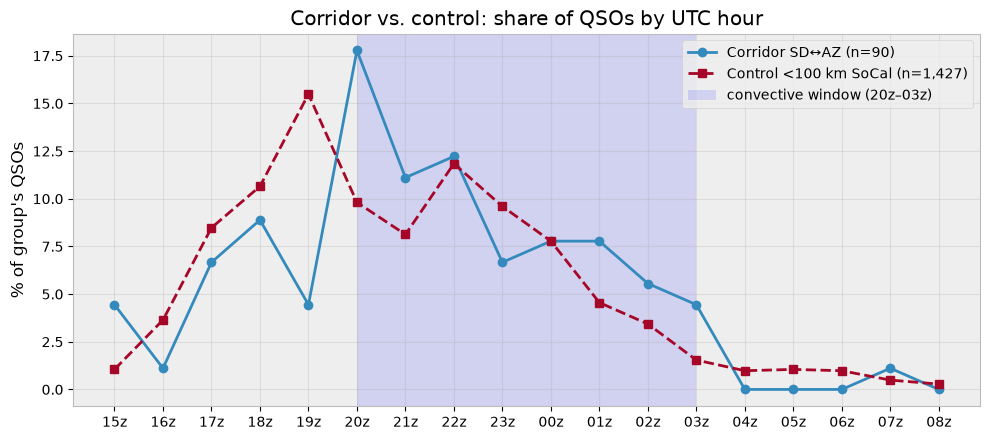

In [3]:
control = df[(df.dist_km < 100) & s1].drop_duplicates("pair_key")

hours = list(range(15, 24)) + list(range(0, 9))   # 15z ... 08z wrap
def hourly_share(d):
    counts = d.ts.dt.hour.value_counts()
    return [100 * counts.get(h, 0) / len(d) for h in hours]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(range(len(hours)), hourly_share(corridor), "o-",
        label=f"Corridor SD↔AZ (n={len(corridor)})")
ax.plot(range(len(hours)), hourly_share(control), "s--",
        label=f"Control <100 km SoCal (n={len(control):,})")
ax.set_xticks(range(len(hours)))
ax.set_xticklabels([f"{h:02d}z" for h in hours])
ax.axvspan(hours.index(20), hours.index(3), alpha=0.12,
           label="convective window (20z–03z)")
ax.set_ylabel("% of group's QSOs")
ax.set_title("Corridor vs. control: share of QSOs by UTC hour")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

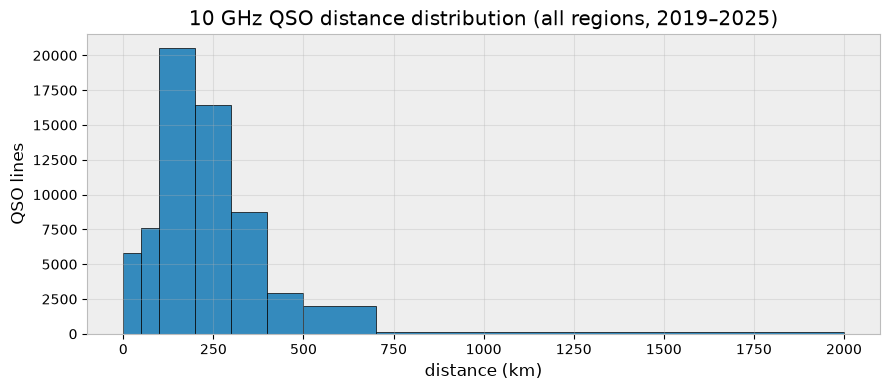

In [4]:
# distance distribution, all 10 GHz QSOs
fig, ax = plt.subplots(figsize=(9, 4))
bins = [0, 50, 100, 200, 300, 400, 500, 700, 2000]
ax.hist(df.dist_km.clip(upper=1999), bins=bins, edgecolor="k")
ax.set_xlabel("distance (km)"); ax.set_ylabel("QSO lines")
ax.set_title("10 GHz QSO distance distribution (all regions, 2019–2025)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Where do operators actually stand? (endpoint shortlist for Step 2)
Ranked 6-char grids on each side of the corridor — the empirical answer to
"which endpoints should the common-volume geometry use." 

In [5]:
print("SoCal-side grids by corridor QSOs:")
print(corridor.groupby("grid1").agg(
    qsos=("pair_key","count"),
    calls=("call1", lambda s: ",".join(sorted(set(s))[:4]))
).sort_values("qsos", ascending=False).head(10))

print("\nAZ-side grids by corridor QSOs:")
print(corridor.groupby("grid2").agg(
    qsos=("pair_key","count"),
    calls=("call2", lambda s: ",".join(sorted(set(s))[:4]))
).sort_values("qsos", ascending=False).head(10))

SoCal-side grids by corridor QSOs:
        qsos                      calls
grid1                                  
DM13JM    15                KK6MXP,W6DL
DM13ET    13  KK6MXP,W6DL,WA6CDR,WA6JBD
DM03UT    10                N6CA,WA6CGR
DM12MQ     7   K6NKC,K6QPV,KN6PKN,N6IZW
DM03WT     6          K6NKC,N6TEB,N6VHF
DM13CO     6                     WA6CDR
DM13BQ     5                     WB6CWN
DM13RB     4                       N7DA
DM14GI     4               N6VHF,WA6JBD
DM13FW     4                      N6VHF

AZ-side grids by corridor QSOs:
        qsos                    calls
grid2                                
DM23XQ    15  AD7OI,KD6W,KI7GVT,N6RMJ
DM34DP     9        K6VHF,N6RMJ,N6VHF
DM25RE     9                    N6RMJ
DM24RV     7                    N6RMJ
DM25SE     7                    N6RMJ
DM25NI     6                    N6RMJ
DM25OD     6                    N6RMJ
DM25QA     6                    N6RMJ
DM25TB     5                    N6RMJ
DM43BO     5                   WB6

In [6]:
# corridor activity by contest weekend (session structure)
corridor["date"] = corridor.ts.dt.date
by_day = corridor.groupby("date").agg(
    qsos=("pair_key","count"),
    max_km=("dist_km","max"),
    az_grids=("grid2", lambda s: ",".join(sorted(set(s))))
).sort_values("qsos", ascending=False)
print("Corridor QSOs by contest day:")
print(by_day.to_string())

Corridor QSOs by contest day:
            qsos      max_km                     az_grids
date                                                     
2022-08-21    16  494.202194  DM25OD,DM25QA,DM25SE,DM43BO
2021-09-18    14  393.152387                       DM23XQ
2022-08-20    11  373.518224                DM24RV,DM25QA
2024-09-21     9  494.202194         DM34DP,DM35KF,DM43BO
2022-08-22     6  356.647950                       DM25NI
2023-08-19     6  376.086287                DM25IE,DM25RE
2019-08-18     5  593.163111                DM25RE,DM45DH
2021-09-19     4  494.202194                DM25TB,DM43BO
2019-08-17     3  288.889334                DM24LT,DM25RE
2024-08-18     3  243.451371                       DM24LV
2024-09-22     2  365.744176                       DM34DP
2024-08-19     2  371.782921                       DM34DP
2022-09-17     2  532.310433                DM23XQ,DM43BO
2023-09-16     2  406.890084                       DM34TF
2021-09-20     2  353.123122              

## Notes
- Labels are **success-only** and **session-clustered**: one rover day contributes
  many correlated QSOs, so effective sample size < row count.
- Propagation mode is **not** recorded; the 15z–16z cluster (2021-09-18) may be
  morning tropo rather than rain scatter. NEXRAD replay (Step 4) classifies.
- The grid tables above feed Step 2: compute common-volume geometry for the
  top grids on each side plus the home/operational endpoint.